## Step 1: Import Libraries

In [1]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Step 2: Load Dataset

In [2]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Step 3: Preprocessing (Padding)

In [3]:
max_len = 200  # max words per review

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
# This ensures all sequences have equal length.

## Step 4: Build LSTM Model

In [4]:
model = Sequential()

# Convert words into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# Stacked LSTM layers with dropout
model.add(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model.add(LSTM(32, dropout=0.2, recurrent_dropout=0.2))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 5: Compile Model

In [5]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Step 6: Train Model

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 189s 579ms/step - accuracy: 0.7668 - loss: 0.4861 - val_accuracy: 0.8228 - val_loss: 0.4024
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 196s 561ms/step - accuracy: 0.8461 - loss: 0.3674 - val_accuracy: 0.8136 - val_loss: 0.4101
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 569ms/step - accuracy: 0.8827 - loss: 0.3005 - val_accuracy: 0.8416 - val_loss: 0.3761
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 177s 563ms/step - accuracy: 0.8819 - loss: 0.2869 - val_accuracy: 0.8478 - val_loss: 0.3903
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 566ms/step - accuracy: 0.9087 - loss: 0.2345 - val_accuracy: 0.8484 - val_loss: 0.3817


## Step 7: Evaluate Model

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8419 - loss: 0.3907
Test Accuracy: 0.8418800234794617


## Plot Graphs

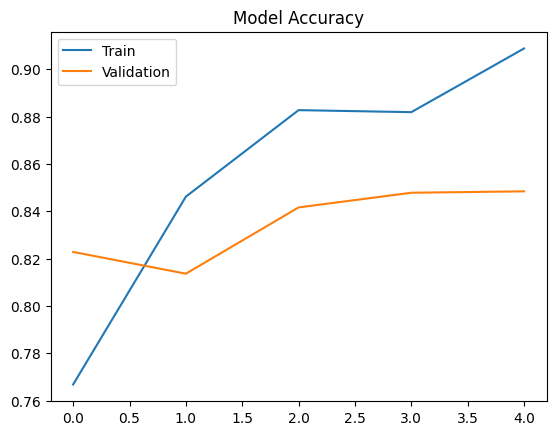

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

## Explanation
*   **Embedding Layer**: Converts words into vectors
*   **LSTM Layer**: Captures sequence dependencies
*   **Sigmoid Output**: Binary classification

## Why LSTM Works Better?
*   Remembers long-term dependencies
*   Avoids vanishing gradient problem
*   Captures context in sentences

## Final Conclusion
The LSTM model effectively captures sequential dependencies in text data, leading to improved classification performance compared to traditional neural networks. It is well-suited for natural language processing tasks such as sentiment analysis.